# Phase 5: Customer Segmentation

## Objective

The objective of this phase is to group customers into meaningful segments based on their purchasing behaviour using unsupervised machine learning.

Customer segmentation helps businesses understand different types of customers, enabling targeted marketing, personalized recommendations, and improved customer relationship management.

In this notebook, we will:

- Load the engineered customer dataset.
- Explore and validate the features.
- Scale the numerical features.
- Visualize customers using PCA.
- Determine the optimal number of clusters.
- Apply K-Means clustering.
- Profile and interpret each customer segment.
- Save the final segmented dataset.

In [73]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [74]:
# ==========================================================
# Load Customer Feature Dataset
# ==========================================================

df = pd.read_csv("../data/processed/customer_features.csv")

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               5878 non-null   float64
 1   Recency                  5878 non-null   int64  
 2   Frequency                5878 non-null   int64  
 3   Monetary                 5878 non-null   float64
 4   TotalQuantity            5878 non-null   int64  
 5   AvgQuantity              5878 non-null   float64
 6   MedianQuantity           5878 non-null   float64
 7   MaxQuantity              5878 non-null   int64  
 8   MinQuantity              5878 non-null   int64  
 9   QuantitySTD              5878 non-null   float64
 10  AvgRevenue               5878 non-null   float64
 11  MedianRevenue            5878 non-null   float64
 12  MaxRevenue               5878 non-null   float64
 13  MinRevenue               5878 non-null   float64
 14  RevenueSTD              

In [76]:
df.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,...,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,Country,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
0,12346.0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,...,35.909091,5.0,-77608.20,29.411765,United Kingdom,6463.038333,0.029925,2.25,-10.0,76810.74
1,12347.0,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,...,57.000000,0.0,0.00,0.000000,Iceland,615.191250,0.019851,15.75,6.0,3698.47
2,12348.0,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,...,90.500000,0.0,0.00,0.000000,Finland,403.880000,0.013774,5.00,3.0,1575.08
3,12349.0,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,...,189.666667,1.0,-24.15,20.000000,Italy,1107.172500,0.007005,34.50,-2.0,-913.59
4,12350.0,310,1,334.40,197,11.588235,12.0,24,1,4.345383,...,0.000000,0.0,0.00,0.000000,Norway,334.400000,1.000000,17.00,1.0,334.40


In [77]:
print("Dataset Shape :", df.shape)
print("Number of Customers :", df["CustomerID"].nunique())

Dataset Shape : (5878, 31)
Number of Customers : 5878


In [78]:
df.isnull().sum()

CustomerID                 0
Recency                    0
Frequency                  0
Monetary                   0
TotalQuantity              0
AvgQuantity                0
MedianQuantity             0
MaxQuantity                0
MinQuantity                0
QuantitySTD                0
AvgRevenue                 0
MedianRevenue              0
MaxRevenue                 0
MinRevenue                 0
RevenueSTD                 0
RevenueRange               0
UniqueProducts             0
AvgProductsPerInvoice      0
ActiveMonths               0
PurchaseSpan               0
WeekendPurchaseRate        0
AvgDaysBetweenPurchases    0
CancelledTransactions      0
CancelledRevenue           0
CancellationRate           0
Country                    0
AverageBasketValue         0
PurchaseVelocity           0
ProductDiversityRatio      0
PurchaseTrend              0
RevenueTrend               0
dtype: int64

### Section Summary

In this section, we loaded the customer feature dataset created during Phase 4 and performed initial validation. We confirmed the dataset structure, checked for missing values, and verified that each row represents a unique customer. The dataset is now ready for exploratory analysis and customer segmentation.

# Section 2: Feature Overview

## Objective

Before applying clustering algorithms, it is important to understand the available features and decide which ones should be used for customer segmentation.

In this section, we will:

- Review all available features.
- Separate numerical and categorical features.
- Exclude identifier and non-clustering columns.
- Create the final feature matrix that will be used for scaling and clustering.

In [79]:
# ==========================================================
# Display All Columns
# ==========================================================

print("Customer Feature Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Customer Feature Columns:

1. CustomerID
2. Recency
3. Frequency
4. Monetary
5. TotalQuantity
6. AvgQuantity
7. MedianQuantity
8. MaxQuantity
9. MinQuantity
10. QuantitySTD
11. AvgRevenue
12. MedianRevenue
13. MaxRevenue
14. MinRevenue
15. RevenueSTD
16. RevenueRange
17. UniqueProducts
18. AvgProductsPerInvoice
19. ActiveMonths
20. PurchaseSpan
21. WeekendPurchaseRate
22. AvgDaysBetweenPurchases
23. CancelledTransactions
24. CancelledRevenue
25. CancellationRate
26. Country
27. AverageBasketValue
28. PurchaseVelocity
29. ProductDiversityRatio
30. PurchaseTrend
31. RevenueTrend


In [80]:
# ==========================================================
# Separate Numerical and Categorical Columns
# ==========================================================

numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'AvgQuantity', 'MedianQuantity', 'MaxQuantity', 'MinQuantity', 'QuantitySTD', 'AvgRevenue', 'MedianRevenue', 'MaxRevenue', 'MinRevenue', 'RevenueSTD', 'RevenueRange', 'UniqueProducts', 'AvgProductsPerInvoice', 'ActiveMonths', 'PurchaseSpan', 'WeekendPurchaseRate', 'AvgDaysBetweenPurchases', 'CancelledTransactions', 'CancelledRevenue', 'CancellationRate', 'AverageBasketValue', 'PurchaseVelocity', 'ProductDiversityRatio', 'PurchaseTrend', 'RevenueTrend']

Categorical Columns:
['Country']


In [81]:
# ==========================================================
# Select Features for Clustering
# ==========================================================

exclude_columns = [
    "CustomerID",   # Identifier
    "Country"       # Categorical feature
]

feature_columns = [
    col for col in numerical_columns
    if col not in exclude_columns
]

X = df[feature_columns]

print("Features used for clustering:")
print(feature_columns)

print("\nNumber of Features:", len(feature_columns))

Features used for clustering:
['Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'AvgQuantity', 'MedianQuantity', 'MaxQuantity', 'MinQuantity', 'QuantitySTD', 'AvgRevenue', 'MedianRevenue', 'MaxRevenue', 'MinRevenue', 'RevenueSTD', 'RevenueRange', 'UniqueProducts', 'AvgProductsPerInvoice', 'ActiveMonths', 'PurchaseSpan', 'WeekendPurchaseRate', 'AvgDaysBetweenPurchases', 'CancelledTransactions', 'CancelledRevenue', 'CancellationRate', 'AverageBasketValue', 'PurchaseVelocity', 'ProductDiversityRatio', 'PurchaseTrend', 'RevenueTrend']

Number of Features: 29


In [82]:
X.head()

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,6463.038333,...,0.000000,35.909091,5.0,-77608.20,29.411765,6463.038333,0.029925,2.25,-10.0,76810.74
1,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,615.191250,...,18.018018,57.000000,0.0,0.00,0.000000,615.191250,0.019851,15.75,6.0,3698.47
2,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,403.880000,...,5.882353,90.500000,0.0,0.00,0.000000,403.880000,0.013774,5.00,3.0,1575.08
3,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,1107.172500,...,0.000000,189.666667,1.0,-24.15,20.000000,1107.172500,0.007005,34.50,-2.0,-913.59
4,310,1,334.40,197,11.588235,12.0,24,1,4.345383,334.400000,...,0.000000,0.000000,0.0,0.00,0.000000,334.400000,1.000000,17.00,1.0,334.40


In [83]:
X.describe().round(2)

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
count,5878.00,5878.00,5878.00,5878.0,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,...,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90,1788.7,25.32,15.75,122.59,6.07,27.40,385.18,...,14.47,73.74,1.33,-174.17,11.75,385.18,0.33,17.68,-0.09,27.82
std,209.34,13.01,14440.85,8876.3,365.07,77.11,1485.33,48.76,637.33,1214.29,...,27.58,95.26,3.67,2685.07,16.55,1214.29,0.49,15.86,4.81,4639.97
min,1.00,1.00,2.95,1.0,1.00,1.00,1.00,1.00,0.00,2.95,...,0.00,0.00,0.00,-168478.59,0.00,2.95,0.00,0.06,-155.00,-79661.86
25%,26.00,1.00,342.28,187.0,5.65,3.00,24.00,1.00,4.86,176.68,...,0.00,0.00,0.00,-30.79,0.00,176.68,0.01,7.61,-2.00,-461.41
50%,96.00,3.00,867.74,480.0,9.60,7.00,48.00,1.00,7.64,279.24,...,0.00,45.35,0.00,0.00,0.00,279.24,0.03,13.88,0.00,-74.98
75%,380.00,7.00,2248.30,1350.0,14.18,12.00,80.00,2.00,12.96,414.90,...,16.12,100.81,1.00,0.00,21.84,414.90,1.00,22.79,1.00,417.01
max,739.00,398.00,580987.04,367193.0,26999.00,2520.00,80995.00,1440.00,46761.91,84236.24,...,100.00,714.00,112.00,0.00,80.00,84236.24,6.00,220.00,78.00,168472.49


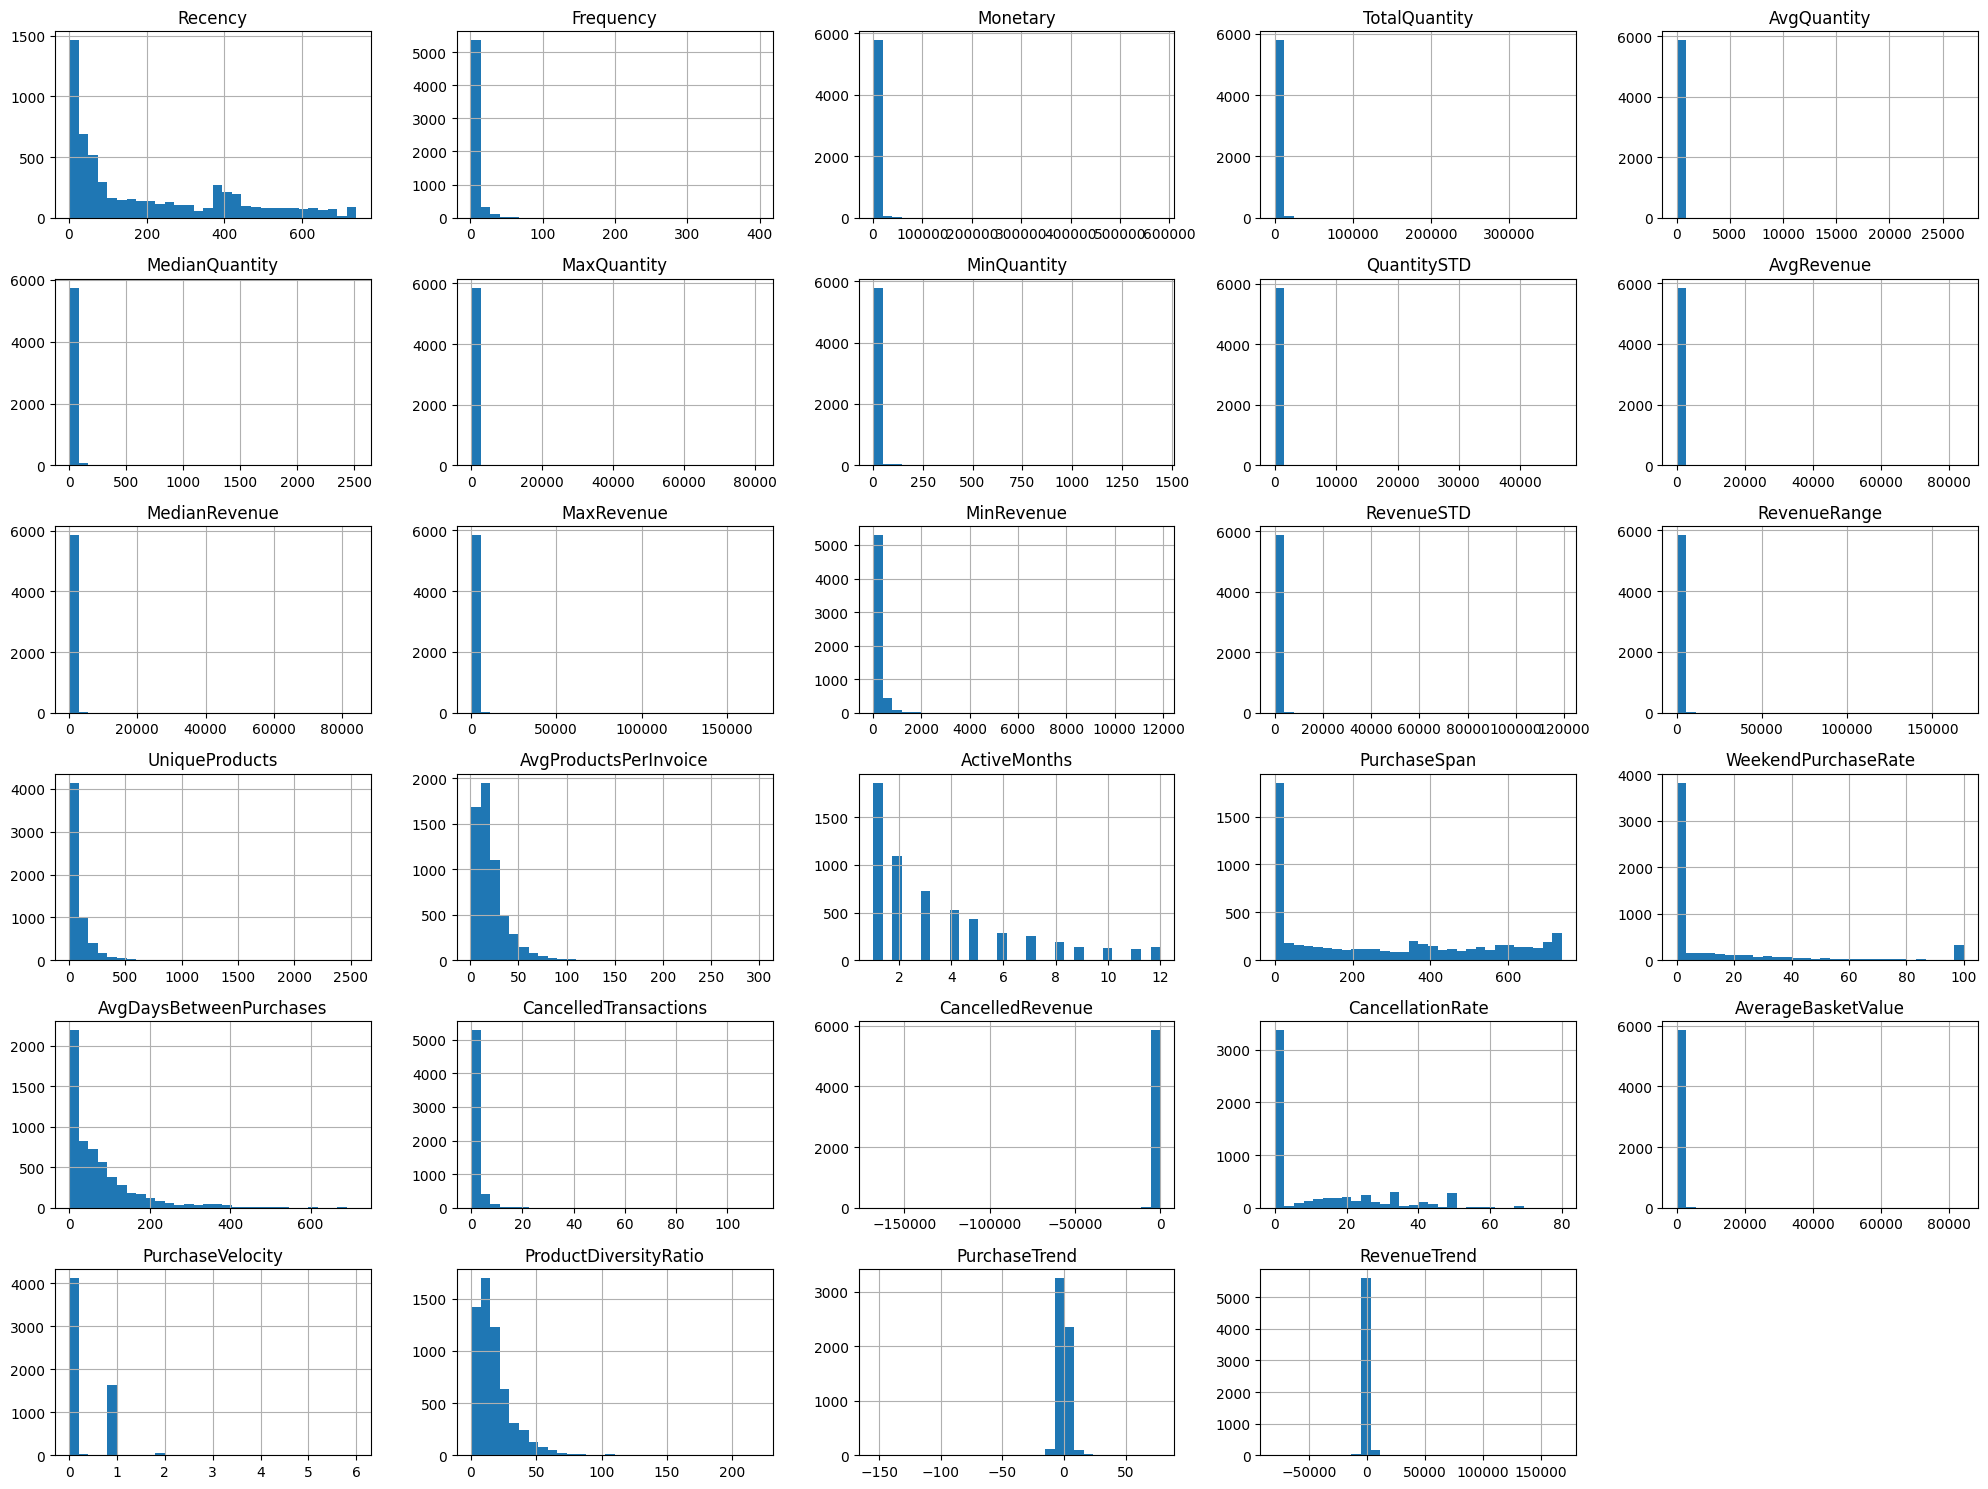

In [84]:
# ==========================================================
# Distribution of Numerical Features
# ==========================================================

X.hist(figsize=(20, 15), bins=30)

plt.tight_layout()
plt.show()

In [85]:
skewness = X.skew().sort_values(ascending=False)

skewness.to_frame("Skewness")

,Skewness
AvgQuantity,69.034483
QuantitySTD,68.529538
RevenueSTD,65.979770
MedianRevenue,59.912546
AvgRevenue,57.132566
AverageBasketValue,57.132566
MaxQuantity,49.119768
RevenueRange,43.778001
MaxRevenue,42.740836
Monetary,25.070190


### Section Summary

In this section, we explored the engineered customer features and prepared the dataset for clustering. Identifier and categorical columns were excluded, leaving only numerical behavioural features for analysis. We also examined summary statistics and feature distributions to better understand the scale and skewness of the data before applying feature scaling.

# Section 3: Correlation Analysis

## Objective

In this section, we analyze the relationships between the numerical features using a correlation matrix.

Understanding feature correlations helps us:

- Identify strongly related features.
- Understand customer purchasing patterns.
- Detect potential redundancy between features.
- Gain insights before applying feature scaling and clustering.

Correlation analysis is used for interpretation only and does not remove any features in this project.

In [86]:
# ==========================================================
# Compute Correlation Matrix
# ==========================================================

correlation_matrix = X.corr()

correlation_matrix.round(2)

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
Recency,1.00,-0.26,-0.12,-0.11,-0.01,0.02,-0.02,0.04,-0.01,-0.03,...,0.00,-0.23,-0.19,0.02,-0.06,-0.03,0.45,0.01,-0.27,-0.11
Frequency,-0.26,1.00,0.63,0.57,0.00,0.01,0.05,-0.03,0.01,0.03,...,-0.01,-0.10,0.78,-0.16,0.09,0.03,-0.21,-0.14,-0.07,-0.07
Monetary,-0.12,0.63,1.00,0.87,0.18,0.08,0.22,0.00,0.18,0.27,...,-0.03,-0.06,0.46,-0.35,0.06,0.27,-0.08,-0.06,-0.12,0.06
TotalQuantity,-0.11,0.57,0.87,1.00,0.21,0.27,0.30,0.01,0.20,0.26,...,-0.03,-0.06,0.41,-0.31,0.06,0.26,-0.08,-0.05,-0.11,0.00
AvgQuantity,-0.01,0.00,0.18,0.21,1.00,0.24,0.79,0.16,0.97,0.92,...,-0.02,0.01,0.01,-0.84,0.03,0.92,-0.00,-0.04,0.00,0.46
MedianQuantity,0.02,0.01,0.08,0.27,0.24,1.00,0.16,0.75,0.08,0.18,...,-0.05,-0.03,0.00,-0.07,-0.00,0.18,0.04,-0.11,-0.01,-0.02
MaxQuantity,-0.02,0.05,0.22,0.30,0.79,0.16,1.00,0.04,0.88,0.73,...,-0.02,0.00,0.04,-0.85,0.04,0.73,-0.03,-0.04,-0.02,0.45
MinQuantity,0.04,-0.03,0.00,0.01,0.16,0.75,0.04,1.00,0.01,0.07,...,-0.04,-0.03,-0.03,-0.02,-0.03,0.07,0.09,-0.10,0.00,0.02
QuantitySTD,-0.01,0.01,0.18,0.20,0.97,0.08,0.88,0.01,1.00,0.90,...,-0.01,0.01,0.01,-0.89,0.04,0.90,-0.02,-0.03,-0.00,0.50
AvgRevenue,-0.03,0.03,0.27,0.26,0.92,0.18,0.73,0.07,0.90,1.00,...,-0.03,0.01,0.05,-0.86,0.09,1.00,0.00,0.07,0.00,0.49


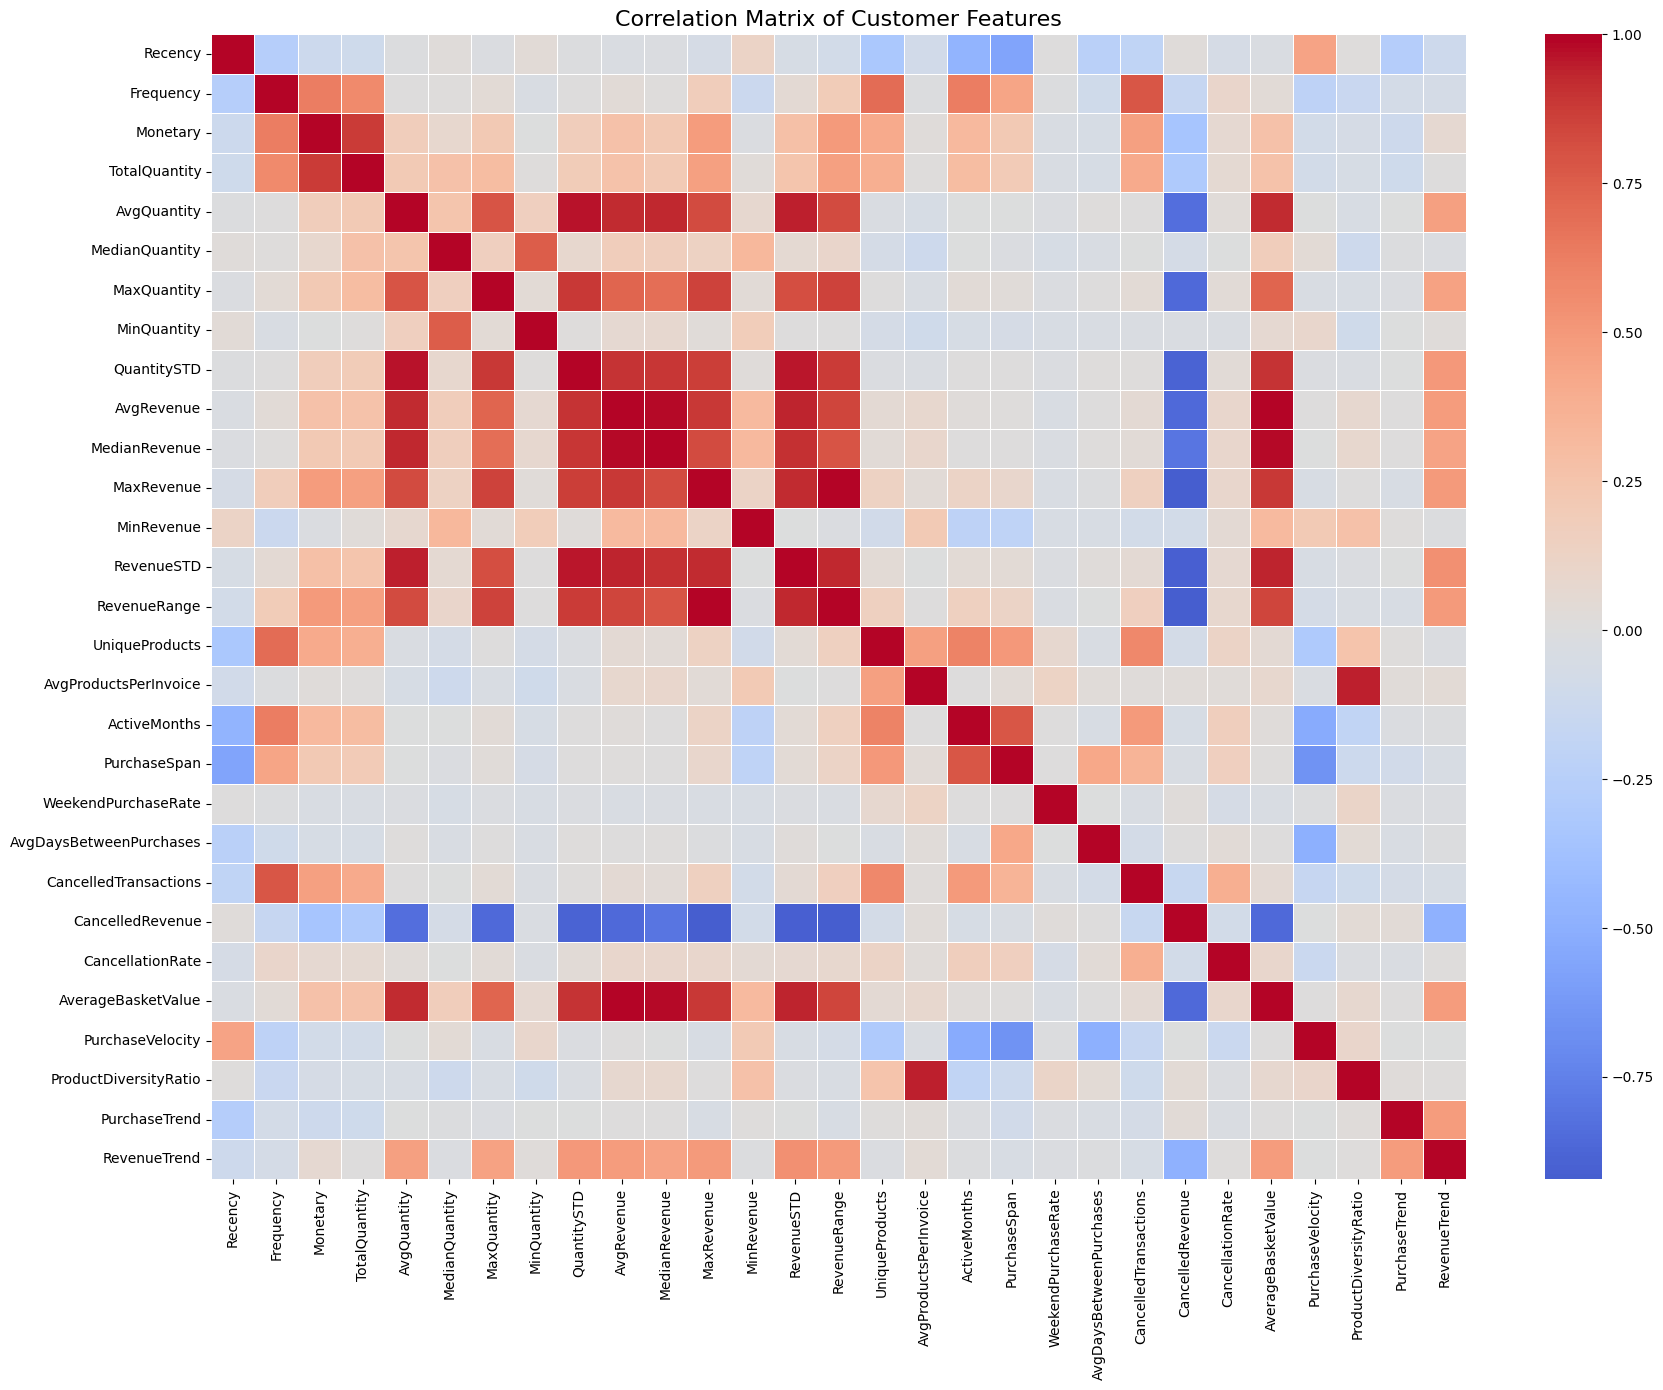

In [87]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Customer Features", fontsize=16)

plt.tight_layout()
plt.show()

In [88]:
# ==========================================================
# Highly Correlated Feature Pairs
# ==========================================================

threshold = 0.80

high_corr = (
    correlation_matrix.abs()
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = high_corr[
    high_corr["Correlation"] >= threshold
].sort_values(
    by="Correlation",
    ascending=False
)

high_corr

,Feature 1,Feature 2,Correlation
230,AvgRevenue,AverageBasketValue,1.000000
255,MaxRevenue,RevenueRange,0.990352
216,AvgRevenue,MedianRevenue,0.983609
248,MedianRevenue,AverageBasketValue,0.983609
109,AvgQuantity,QuantitySTD,0.968602
200,QuantitySTD,RevenueSTD,0.962469
114,AvgQuantity,RevenueSTD,0.943210
337,AvgProductsPerInvoice,ProductDiversityRatio,0.940770
219,AvgRevenue,RevenueSTD,0.938994
296,RevenueSTD,AverageBasketValue,0.938994


In [89]:
high_corr.head(10)

,Feature 1,Feature 2,Correlation
230,AvgRevenue,AverageBasketValue,1.000000
255,MaxRevenue,RevenueRange,0.990352
216,AvgRevenue,MedianRevenue,0.983609
248,MedianRevenue,AverageBasketValue,0.983609
109,AvgQuantity,QuantitySTD,0.968602
200,QuantitySTD,RevenueSTD,0.962469
114,AvgQuantity,RevenueSTD,0.943210
337,AvgProductsPerInvoice,ProductDiversityRatio,0.940770
219,AvgRevenue,RevenueSTD,0.938994
296,RevenueSTD,AverageBasketValue,0.938994


In [90]:
# ==========================================================
# Features Most Related to Monetary
# ==========================================================

correlation_matrix["Monetary"]\
    .sort_values(ascending=False)\
    .to_frame("Correlation with Monetary")

,Correlation with Monetary
Monetary,1.000000
TotalQuantity,0.874546
Frequency,0.627920
RevenueRange,0.491838
MaxRevenue,0.486256
CancelledTransactions,0.459909
UniqueProducts,0.407911
ActiveMonths,0.317394
RevenueSTD,0.272927
AverageBasketValue,0.268907


### Section Summary

In this section, we examined the relationships between customer features using a correlation matrix. The heatmap helped visualize how different behavioural features are related, while highly correlated feature pairs were identified for interpretation.

Although some features are strongly correlated (such as spending and purchase-related metrics), all engineered features are retained because each captures a different aspect of customer behaviour and contributes to meaningful customer segmentation.

# Section 4: Feature Scaling

## Objective

Customer features have different units and value ranges. For example, revenue-related features may have values in the thousands, while percentage-based features range from 0 to 100.

Since K-Means clustering uses Euclidean distance, features with larger magnitudes can dominate the clustering process.

To ensure that every feature contributes equally, we standardize all numerical features using **StandardScaler**, which transforms each feature to have:

- Mean ≈ 0
- Standard Deviation ≈ 1

The scaled data will be used for PCA and K-Means clustering.

In [91]:
# ==========================================================
# Standardize Numerical Features
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [92]:
# ==========================================================
# Convert Scaled Data to DataFrame
# ==========================================================

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled.head()

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
0,0.595584,0.438998,5.166378,8.168099,5.915978,-0.191360,49.887133,-0.103968,19.928639,5.005717,...,-0.524574,-0.397140,0.998589,-28.841198,1.067154,5.005717,-0.606089,-0.973055,-2.058700,16.549567
1,-0.952279,0.131502,0.136127,0.132759,-0.032748,-0.048693,0.079053,-0.083459,-0.015794,0.189436,...,0.128795,-0.175723,-0.363039,0.064871,-0.710260,0.189436,-0.626642,-0.121531,1.265704,0.791161
2,-0.603532,-0.099120,-0.064857,0.104253,0.076422,0.106944,0.014415,-0.103968,0.033421,0.015401,...,-0.311269,0.175968,-0.363039,0.064871,-0.710260,0.015401,-0.639040,-0.799596,0.642378,0.333492
3,-0.871064,-0.175994,0.101996,-0.018556,-0.043939,-0.126511,-0.050223,-0.103968,-0.030806,0.594632,...,-0.524574,1.217042,-0.090713,0.055876,0.498381,0.594632,-0.652849,1.061140,-0.396498,-0.202909
4,0.519146,-0.406616,-0.181549,-0.179335,-0.037616,-0.048693,-0.066382,-0.103968,-0.036181,-0.041823,...,-0.524574,-0.774122,-0.363039,0.064871,-0.710260,-0.041823,1.373023,-0.042687,0.226828,0.066079


In [93]:
X_scaled.describe().round(2)

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
count,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,...,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00
mean,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,...,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.96,-0.41,-0.20,-0.20,-0.07,-0.19,-0.08,-0.10,-0.04,-0.31,...,-0.52,-0.77,-0.36,-62.69,-0.71,-0.31,-0.66,-1.11,-32.19,-17.18
25%,-0.84,-0.41,-0.18,-0.18,-0.05,-0.17,-0.07,-0.10,-0.04,-0.17,...,-0.52,-0.77,-0.36,0.05,-0.71,-0.17,-0.64,-0.64,-0.40,-0.11
50%,-0.50,-0.25,-0.14,-0.15,-0.04,-0.11,-0.05,-0.10,-0.03,-0.09,...,-0.52,-0.30,-0.36,0.06,-0.71,-0.09,-0.61,-0.24,0.02,-0.02
75%,0.85,0.05,-0.05,-0.05,-0.03,-0.05,-0.03,-0.08,-0.02,0.02,...,0.06,0.28,-0.09,0.06,0.61,0.02,1.37,0.32,0.23,0.08
max,2.57,30.11,40.03,41.17,73.89,32.48,54.45,29.41,73.34,69.06,...,3.10,6.72,30.14,0.06,4.12,69.06,11.57,12.76,16.23,36.31


In [94]:
scaling_summary = pd.DataFrame({
    "Mean": X_scaled.mean(),
    "Standard Deviation": X_scaled.std()
})

scaling_summary.round(2)

,Mean,Standard Deviation
Recency,-0.0,1.0
Frequency,-0.0,1.0
Monetary,-0.0,1.0
TotalQuantity,-0.0,1.0
AvgQuantity,0.0,1.0
MedianQuantity,0.0,1.0
MaxQuantity,0.0,1.0
MinQuantity,-0.0,1.0
QuantitySTD,-0.0,1.0
AvgRevenue,-0.0,1.0


In [95]:
print("Original Features")
display(X.head())

print("\nScaled Features")
display(X_scaled.head())

Original Features


,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,6463.038333,...,0.000000,35.909091,5.0,-77608.20,29.411765,6463.038333,0.029925,2.25,-10.0,76810.74
1,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,615.191250,...,18.018018,57.000000,0.0,0.00,0.000000,615.191250,0.019851,15.75,6.0,3698.47
2,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,403.880000,...,5.882353,90.500000,0.0,0.00,0.000000,403.880000,0.013774,5.00,3.0,1575.08
3,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,1107.172500,...,0.000000,189.666667,1.0,-24.15,20.000000,1107.172500,0.007005,34.50,-2.0,-913.59
4,310,1,334.40,197,11.588235,12.0,24,1,4.345383,334.400000,...,0.000000,0.000000,0.0,0.00,0.000000,334.400000,1.000000,17.00,1.0,334.40



Scaled Features


,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
0,0.595584,0.438998,5.166378,8.168099,5.915978,-0.191360,49.887133,-0.103968,19.928639,5.005717,...,-0.524574,-0.397140,0.998589,-28.841198,1.067154,5.005717,-0.606089,-0.973055,-2.058700,16.549567
1,-0.952279,0.131502,0.136127,0.132759,-0.032748,-0.048693,0.079053,-0.083459,-0.015794,0.189436,...,0.128795,-0.175723,-0.363039,0.064871,-0.710260,0.189436,-0.626642,-0.121531,1.265704,0.791161
2,-0.603532,-0.099120,-0.064857,0.104253,0.076422,0.106944,0.014415,-0.103968,0.033421,0.015401,...,-0.311269,0.175968,-0.363039,0.064871,-0.710260,0.015401,-0.639040,-0.799596,0.642378,0.333492
3,-0.871064,-0.175994,0.101996,-0.018556,-0.043939,-0.126511,-0.050223,-0.103968,-0.030806,0.594632,...,-0.524574,1.217042,-0.090713,0.055876,0.498381,0.594632,-0.652849,1.061140,-0.396498,-0.202909
4,0.519146,-0.406616,-0.181549,-0.179335,-0.037616,-0.048693,-0.066382,-0.103968,-0.036181,-0.041823,...,-0.524574,-0.774122,-0.363039,0.064871,-0.710260,-0.041823,1.373023,-0.042687,0.226828,0.066079


### Section Summary

In this section, all numerical customer features were standardized using StandardScaler. The transformed dataset has approximately zero mean and unit standard deviation, ensuring that every feature contributes equally during clustering.

The scaled feature matrix (`X_scaled`) will be used in the next steps for PCA visualization and K-Means clustering.

# Section 5: Principal Component Analysis (PCA)

## Objective

The customer feature dataset contains many numerical variables, making it difficult to visualize directly.

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms the original features into a smaller set of uncorrelated components while preserving most of the variation in the data.

In this section, we will:

- Apply PCA to the scaled customer features.
- Measure the variance explained by each principal component.
- Reduce the data to two principal components.
- Visualize customers in a two-dimensional space.

**Note:** PCA is used only for visualization in this project. K-Means clustering will still be performed using the complete scaled feature set.

In [96]:
# ==========================================================
# Apply PCA
# ==========================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [97]:
# ==========================================================
# Apply PCA
# ==========================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [98]:
# ==========================================================
# Explained Variance
# ==========================================================

explained_variance = pca.explained_variance_ratio_

print(f"PC1 Explained Variance : {explained_variance[0]:.2%}")
print(f"PC2 Explained Variance : {explained_variance[1]:.2%}")
print(f"Total Explained Variance : {explained_variance.sum():.2%}")

PC1 Explained Variance : 32.93%
PC2 Explained Variance : 15.63%
Total Explained Variance : 48.56%


In [99]:
# ==========================================================
# PCA DataFrame
# ==========================================================

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,59.335195,-2.380135
1,0.567187,0.827418
2,0.121293,0.055081
3,0.951190,0.994513
4,-0.440707,-1.930827


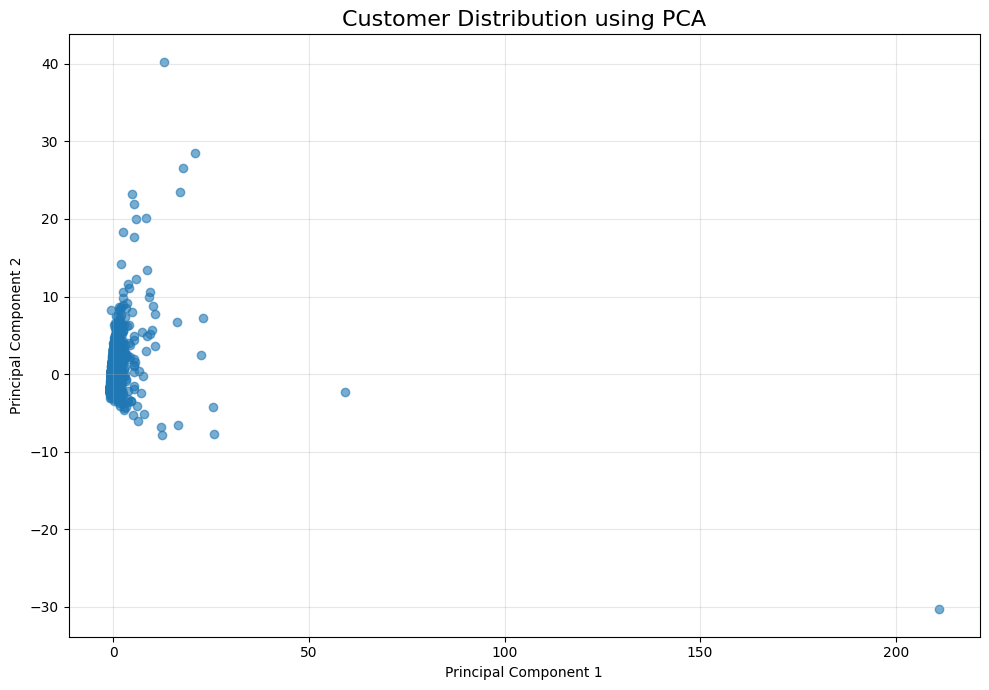

In [100]:
# ==========================================================
# PCA Scatter Plot
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.6
)

plt.title("Customer Distribution using PCA", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [101]:
# ==========================================================
# Top Features Contributing to PC1
# ==========================================================

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

pc1_importance = (
    pca_loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .to_frame("Importance")
)

display(pc1_importance)

,Importance
RevenueSTD,0.312780
MaxRevenue,0.312148
RevenueRange,0.308353
AvgRevenue,0.307762
AverageBasketValue,0.307762
QuantitySTD,0.304783
CancelledRevenue,0.302020
AvgQuantity,0.299483
MedianRevenue,0.296717
MaxQuantity,0.276421


### Section Summary

In this section, PCA was applied to reduce the high-dimensional customer feature space to two principal components. The transformed data provides a simplified visual representation of customer behaviour while retaining a significant portion of the original information.

The PCA projection will be used later to visualize the customer segments identified by the K-Means algorithm.

# Section 6: Determine the Optimal Number of Clusters

## Objective

K-Means clustering requires specifying the number of clusters (K) before training the model.

Selecting an inappropriate value of K may lead to poor customer segmentation.

In this section, we evaluate different values of K using two widely adopted techniques:

- **Elbow Method** – Measures the Within-Cluster Sum of Squares (WCSS).
- **Silhouette Score** – Measures how well-separated the clusters are.

The optimal value of K will be selected by considering both methods.

In [102]:
# ==========================================================
# Evaluate K Values
# ==========================================================

k_values = range(2, 11)

wcss = []
silhouette_scores = []

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    wcss.append(kmeans.inertia_)
    
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

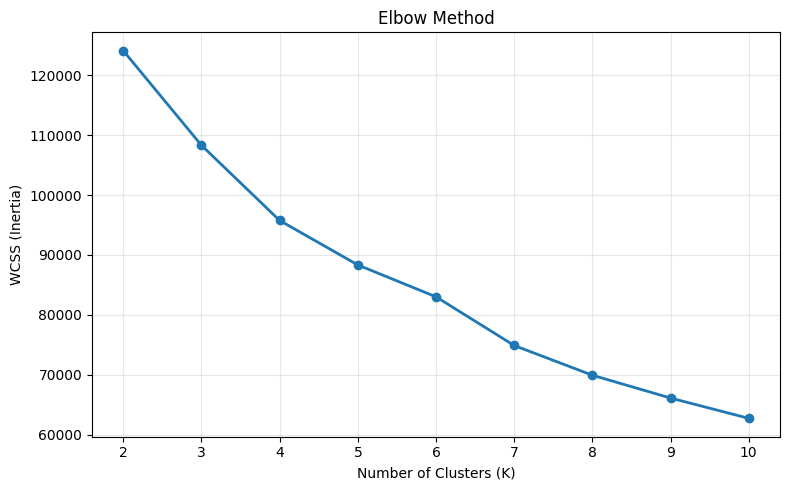

In [103]:
# ==========================================================
# Elbow Curve
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.xticks(k_values)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/figures/elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

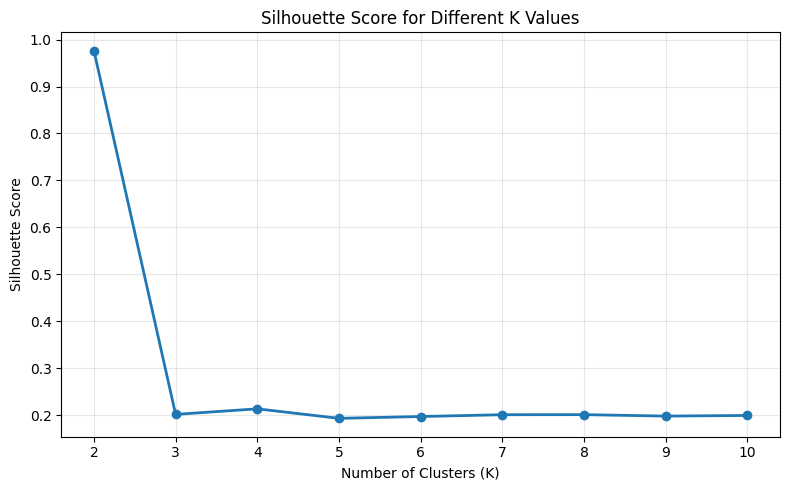

In [104]:
# ==========================================================
# Silhouette Scores
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o",
    linewidth=2
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/figures/silhouette_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [105]:
evaluation_df = pd.DataFrame({
    "K": list(k_values),
    "WCSS": wcss,
    "Silhouette Score": silhouette_scores
})

evaluation_df

,K,WCSS,Silhouette Score
0,2,124119.556997,0.976351
1,3,108314.453289,0.201454
2,4,95755.567898,0.213285
3,5,88325.573875,0.193031
4,6,83002.805077,0.196900
5,7,74870.666542,0.200760
6,8,69904.335175,0.200914
7,9,66093.073788,0.197822
8,10,62700.847017,0.199180


In [106]:
best_k = evaluation_df.loc[
    evaluation_df["Silhouette Score"].idxmax(),
    "K"
]

best_score = evaluation_df["Silhouette Score"].max()

print(f"Best K (Silhouette): {best_k}")
print(f"Best Silhouette Score: {best_score:.3f}")

Best K (Silhouette): 2
Best Silhouette Score: 0.976


In [107]:
print("Selected Number of Clusters:", best_k)

Selected Number of Clusters: 2


### Section Summary

In this section, we evaluated multiple values of K using both the Elbow Method and the Silhouette Score.

The Elbow Method identified the point where adding more clusters provides diminishing improvements in WCSS, while the Silhouette Score measured how well-separated the resulting clusters are.

Based on these evaluation metrics and business interpretability, an appropriate value of K was selected for customer segmentation.

# Section 7: K-Means Clustering

## Objective

After determining the optimal number of clusters, we train the final K-Means clustering model using the standardized customer features.

In this section, we will:

- Train the final K-Means model.
- Assign every customer to a cluster.
- Add the cluster labels to the customer dataset.
- Examine the size of each customer segment.

The generated cluster labels will be used in the remaining sections for profiling, visualization, and business analysis.

In [108]:
# Final K selected after evaluating both metrics
optimal_k = 4

print(f"Final Selected K: {optimal_k}")

Final Selected K: 4


In [109]:
# ==========================================================
# Train Final K-Means Model
# ==========================================================

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [110]:
# ==========================================================
# Add Cluster Labels
# ==========================================================

df["Cluster"] = clusters

df.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,...,CancelledTransactions,CancelledRevenue,CancellationRate,Country,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend,Cluster
0,12346.0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,...,5.0,-77608.20,29.411765,United Kingdom,6463.038333,0.029925,2.25,-10.0,76810.74,3
1,12347.0,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,...,0.0,0.00,0.000000,Iceland,615.191250,0.019851,15.75,6.0,3698.47,1
2,12348.0,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,...,0.0,0.00,0.000000,Finland,403.880000,0.013774,5.00,3.0,1575.08,1
3,12349.0,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,...,1.0,-24.15,20.000000,Italy,1107.172500,0.007005,34.50,-2.0,-913.59,1
4,12350.0,310,1,334.40,197,11.588235,12.0,24,1,4.345383,...,0.0,0.00,0.000000,Norway,334.400000,1.000000,17.00,1.0,334.40,0


In [111]:
# ==========================================================
# Number of Customers in Each Cluster
# ==========================================================

cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    2434
1    3418
2       1
3      25
Name: count, dtype: int64

In [112]:
cluster_percentage = (
    df["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

cluster_percentage

Cluster
0    41.41
1    58.15
2     0.02
3     0.43
Name: proportion, dtype: float64

In [113]:
cluster_summary = pd.DataFrame({
    "Customers": cluster_counts,
    "Percentage (%)": cluster_percentage
})

cluster_summary

,Customers,Percentage (%)
Cluster,,
0,2434,41.41
1,3418,58.15
2,1,0.02
3,25,0.43


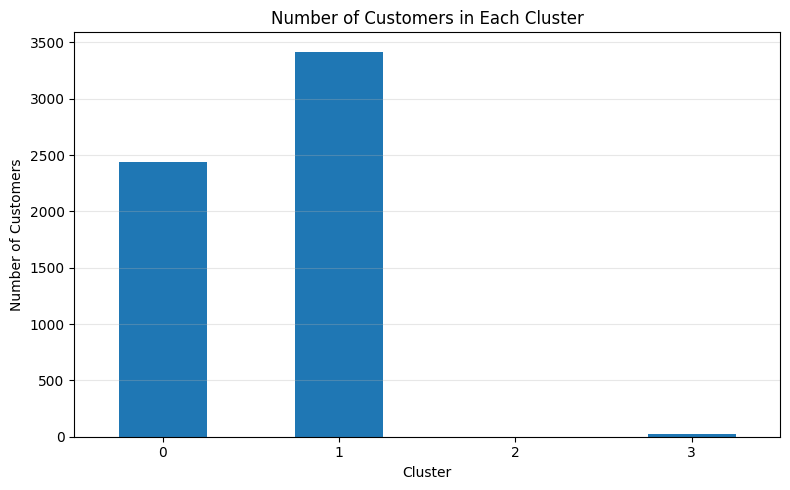

In [114]:
# ==========================================================
# Cluster Distribution
# ==========================================================

plt.figure(figsize=(8,5))

cluster_summary["Customers"].plot(
    kind="bar"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [115]:
# ==========================================================
# Cluster Centers (Scaled Features)
# ==========================================================

cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_scaled.columns
)

cluster_centers.round(2)

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
0,0.72,-0.36,-0.17,-0.16,-0.01,0.03,-0.05,0.09,-0.02,-0.04,...,-0.02,-0.60,-0.30,0.05,-0.24,-0.04,0.88,0.08,-0.05,-0.03
1,-0.50,0.19,0.04,0.04,-0.02,-0.04,-0.01,-0.06,-0.01,-0.01,...,0.02,0.43,0.16,0.02,0.17,-0.01,-0.62,-0.05,0.04,-0.00
2,-0.96,-0.33,11.46,8.92,73.89,-0.19,54.45,-0.10,73.34,69.06,...,-0.52,1.37,0.18,-62.69,2.31,69.06,-0.65,-1.02,0.43,36.31
3,-0.67,8.99,10.40,10.62,0.98,2.87,3.17,0.46,1.21,2.22,...,-0.35,-0.67,7.36,-4.75,0.50,2.22,-0.07,-0.76,-0.93,1.78


### Section Summary

In this section, the final K-Means clustering model was trained using the selected number of clusters. Each customer was assigned to a segment, and the cluster labels were added to the dataset.

We also examined the number of customers in each cluster and inspected the cluster centers in the standardized feature space. These cluster assignments will now be used to understand the characteristics of each customer segment.

# Section 8: Cluster Profiling

## Objective

After assigning customers to clusters, the next step is to understand the characteristics of each segment.

Cluster profiling helps answer questions such as:

- Which customers spend the most?
- Which customers purchase most frequently?
- Which customers are becoming inactive?
- Which customers purchase the widest variety of products?

In this section, we calculate the average value of each feature within every cluster. These statistics will later be used to assign meaningful business names to the customer segments.

In [116]:
# ==========================================================
# Cluster-wise Feature Means
# ==========================================================

cluster_profile = df.groupby("Cluster")[feature_columns].mean()

cluster_profile.round(2)

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,WeekendPurchaseRate,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend
Cluster,,,,,,,,,,,,,,,,,,,,,
0,350.99,1.57,532.81,344.72,20.84,17.79,54.56,10.23,12.14,340.07,...,13.91,16.59,0.24,-50.26,7.73,340.07,0.76,19.00,-0.35,-120.52
1,95.84,8.79,3534.28,2104.41,18.00,12.69,112.98,2.95,18.96,373.09,...,14.94,114.86,1.91,-119.98,14.54,373.09,0.02,16.83,0.12,23.67
2,1.00,2.00,168472.49,80997.00,26999.00,1.00,80995.00,1.00,46761.91,84236.24,...,0.00,204.00,2.00,-168478.59,50.00,84236.24,0.01,1.50,2.00,168472.49
3,61.36,123.28,153172.21,96040.96,382.64,237.00,4826.28,28.32,798.50,3076.71,...,4.71,9.80,28.36,-12915.50,19.99,3076.71,0.29,5.56,-4.56,8299.64


In [117]:
# ==========================================================
# Customers in Each Cluster
# ==========================================================

cluster_sizes = (
    df.groupby("Cluster")
      .size()
      .rename("CustomerCount")
)

cluster_sizes

Cluster
0    2434
1    3418
2       1
3      25
Name: CustomerCount, dtype: int64

In [118]:
# ==========================================================
# Add Customer Count to Cluster Profile
# ==========================================================

cluster_profile = cluster_profile.copy()

cluster_profile["CustomerCount"] = cluster_sizes

cluster_profile.round(2)

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend,CustomerCount
Cluster,,,,,,,,,,,,,,,,,,,,,
0,350.99,1.57,532.81,344.72,20.84,17.79,54.56,10.23,12.14,340.07,...,16.59,0.24,-50.26,7.73,340.07,0.76,19.00,-0.35,-120.52,2434
1,95.84,8.79,3534.28,2104.41,18.00,12.69,112.98,2.95,18.96,373.09,...,114.86,1.91,-119.98,14.54,373.09,0.02,16.83,0.12,23.67,3418
2,1.00,2.00,168472.49,80997.00,26999.00,1.00,80995.00,1.00,46761.91,84236.24,...,204.00,2.00,-168478.59,50.00,84236.24,0.01,1.50,2.00,168472.49,1
3,61.36,123.28,153172.21,96040.96,382.64,237.00,4826.28,28.32,798.50,3076.71,...,9.80,28.36,-12915.50,19.99,3076.71,0.29,5.56,-4.56,8299.64,25


In [119]:
cluster_profile.T.round(2)

Cluster,0,1,2,3
Recency,350.99,95.84,1.00,61.36
Frequency,1.57,8.79,2.00,123.28
Monetary,532.81,3534.28,168472.49,153172.21
TotalQuantity,344.72,2104.41,80997.00,96040.96
AvgQuantity,20.84,18.00,26999.00,382.64
MedianQuantity,17.79,12.69,1.00,237.00
MaxQuantity,54.56,112.98,80995.00,4826.28
MinQuantity,10.23,2.95,1.00,28.32
QuantitySTD,12.14,18.96,46761.91,798.50
AvgRevenue,340.07,373.09,84236.24,3076.71


In [120]:
# ==========================================================
# Cluster Ranking by Monetary Value
# ==========================================================

cluster_profile["Monetary"]\
    .sort_values(ascending=False)\
    .to_frame("Average Monetary")

,Average Monetary
Cluster,
2,168472.490000
3,153172.214000
1,3534.276229
0,532.814400


In [121]:
# ==========================================================
# Cluster Ranking by Monetary Value
# ==========================================================

cluster_profile["Monetary"]\
    .sort_values(ascending=False)\
    .to_frame("Average Monetary")

,Average Monetary
Cluster,
2,168472.490000
3,153172.214000
1,3534.276229
0,532.814400


In [122]:
cluster_profile["Frequency"]\
    .sort_values(ascending=False)\
    .to_frame("Average Frequency")

,Average Frequency
Cluster,
3,123.280000
1,8.794909
2,2.000000
0,1.571076


In [123]:
cluster_profile["Recency"]\
    .sort_values()\
    .to_frame("Average Recency")

,Average Recency
Cluster,
2,1.000000
3,61.360000
1,95.840257
0,350.990961


### Remember 
- Lower Recency = More Recent Purchases
- Higher Recency = Customers haven't purchased for a long time

In [124]:
cluster_profile.round(2).to_csv(
    "../data/processed/cluster_profile.csv"
)

cluster_profile.round(2)

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend,CustomerCount
Cluster,,,,,,,,,,,,,,,,,,,,,
0,350.99,1.57,532.81,344.72,20.84,17.79,54.56,10.23,12.14,340.07,...,16.59,0.24,-50.26,7.73,340.07,0.76,19.00,-0.35,-120.52,2434
1,95.84,8.79,3534.28,2104.41,18.00,12.69,112.98,2.95,18.96,373.09,...,114.86,1.91,-119.98,14.54,373.09,0.02,16.83,0.12,23.67,3418
2,1.00,2.00,168472.49,80997.00,26999.00,1.00,80995.00,1.00,46761.91,84236.24,...,204.00,2.00,-168478.59,50.00,84236.24,0.01,1.50,2.00,168472.49,1
3,61.36,123.28,153172.21,96040.96,382.64,237.00,4826.28,28.32,798.50,3076.71,...,9.80,28.36,-12915.50,19.99,3076.71,0.29,5.56,-4.56,8299.64,25


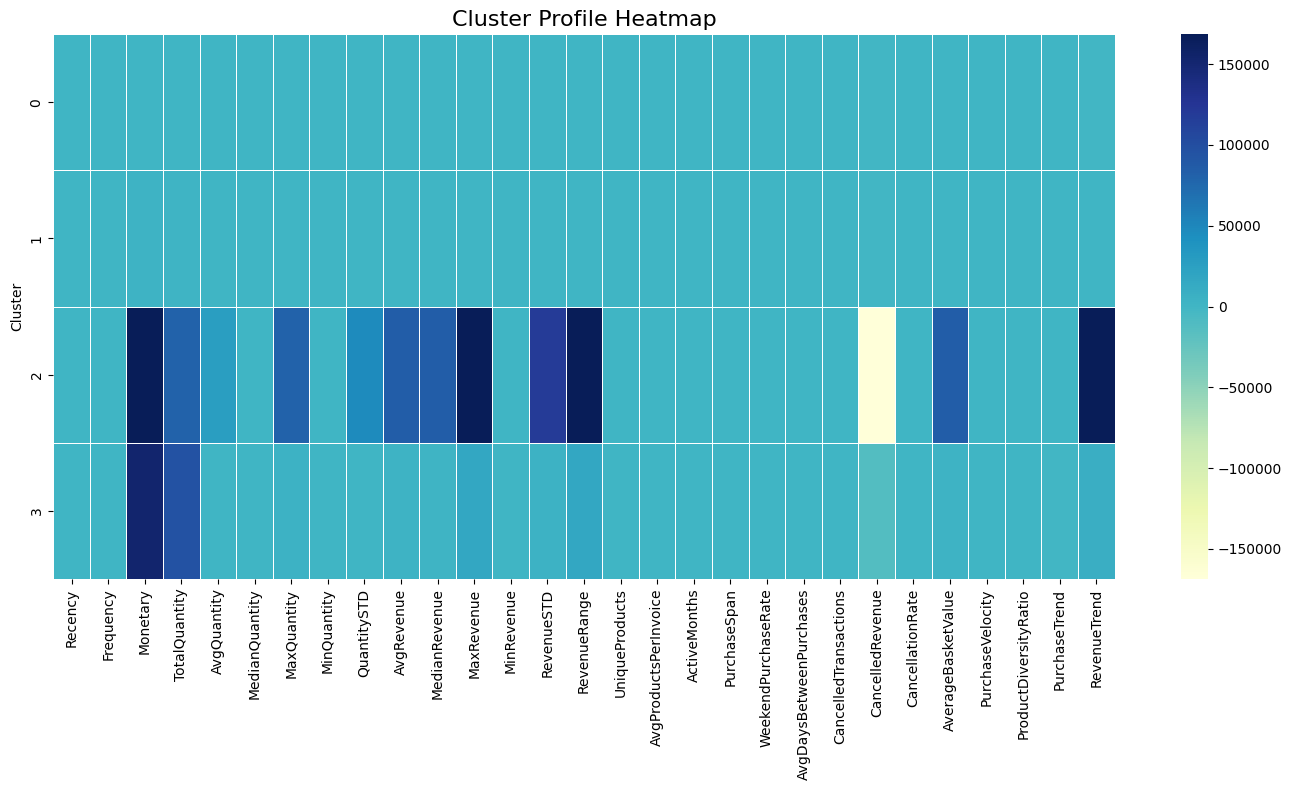

In [125]:
# ==========================================================
# Cluster Profile Heatmap
# ==========================================================

plt.figure(figsize=(14,8))

sns.heatmap(
    cluster_profile.drop(columns="CustomerCount"),
    annot=False,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Cluster Profile Heatmap", fontsize=16)

plt.tight_layout()

plt.savefig(
    "../reports/figures/cluster_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Section Summary

In this section, we profiled each customer cluster by calculating the average value of every numerical feature.

The resulting cluster profile provides a comprehensive view of customer behaviour across all segments. These profiles serve as the foundation for assigning meaningful business labels and generating actionable business insights in the following sections.

# Section 9: Cluster Visualization

## Objective

Visualizing customer segments helps us understand how the clusters are distributed and how they differ from one another.

In this section, we will:

- Visualize customer clusters using the PCA projection.
- Compare the average revenue across clusters.
- Compare the average purchase frequency across clusters.
- Compare the average recency across clusters.

These visualizations make it easier to interpret the customer segments and communicate business insights.

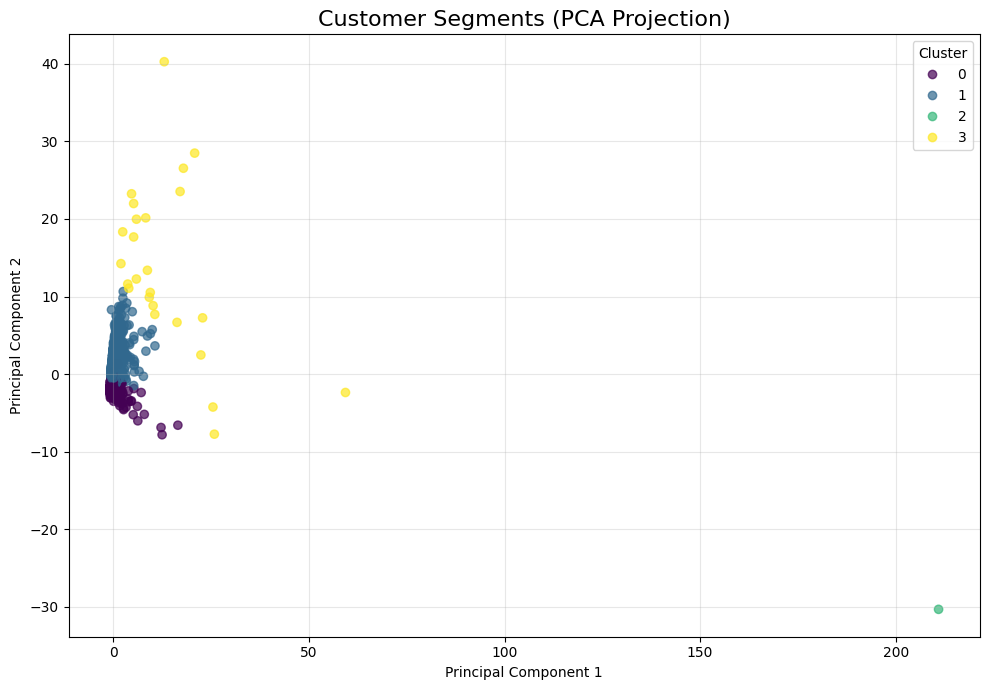

In [126]:
# ==========================================================
# Customer Segments (PCA Projection)
# ==========================================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("Customer Segments (PCA Projection)", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/figures/customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

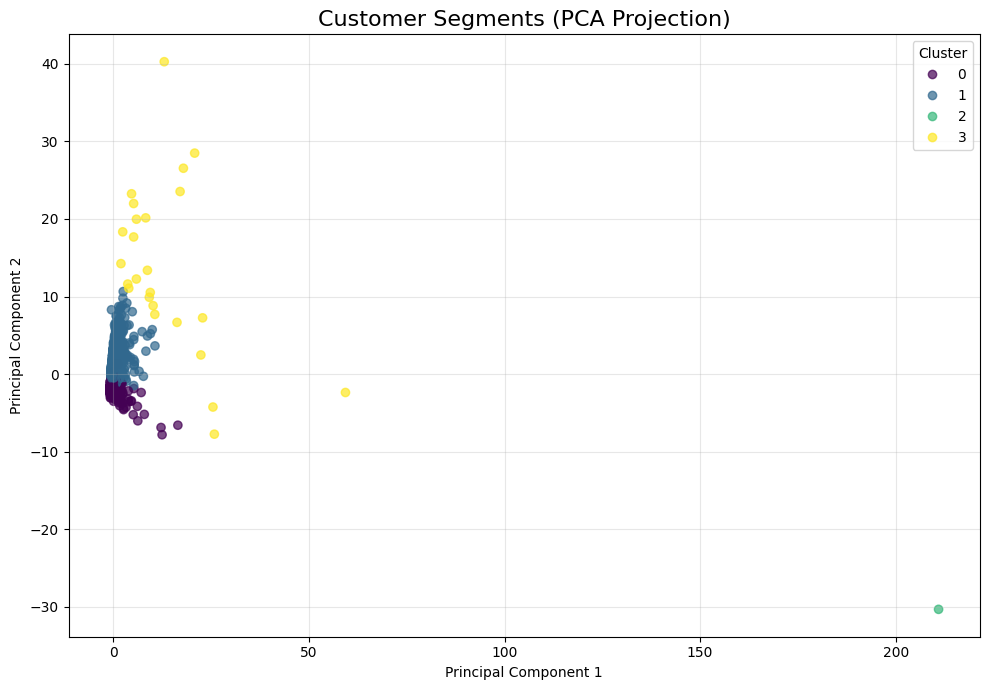

In [127]:
# ==========================================================
# Customer Segments (PCA Projection)
# ==========================================================

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("Customer Segments (PCA Projection)", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/figures/customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

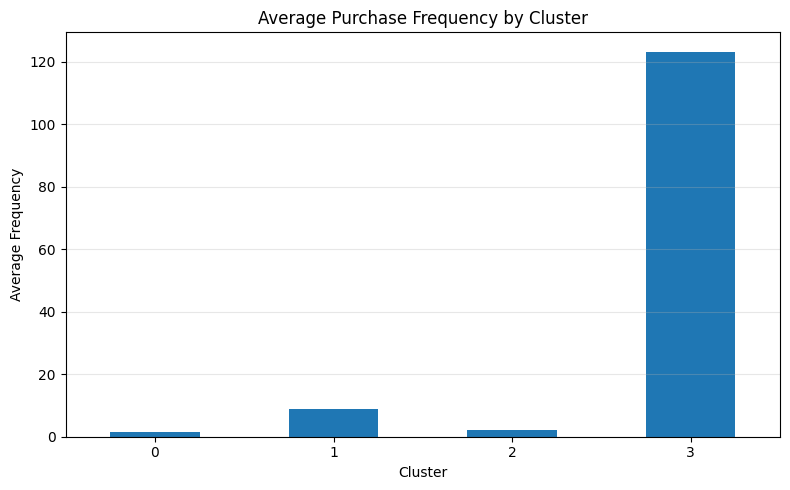

In [128]:
# ==========================================================
# Average Purchase Frequency
# ==========================================================

plt.figure(figsize=(8,5))

cluster_profile["Frequency"].plot(kind="bar")

plt.title("Average Purchase Frequency by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Frequency")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/figures/frequency_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

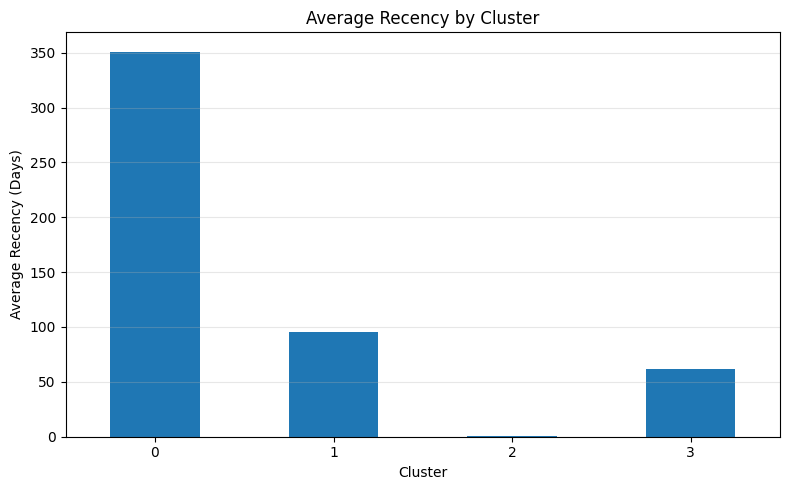

In [129]:
# ==========================================================
# Average Recency
# ==========================================================

plt.figure(figsize=(8,5))

cluster_profile["Recency"].plot(kind="bar")

plt.title("Average Recency by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Recency (Days)")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/figures/recency_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

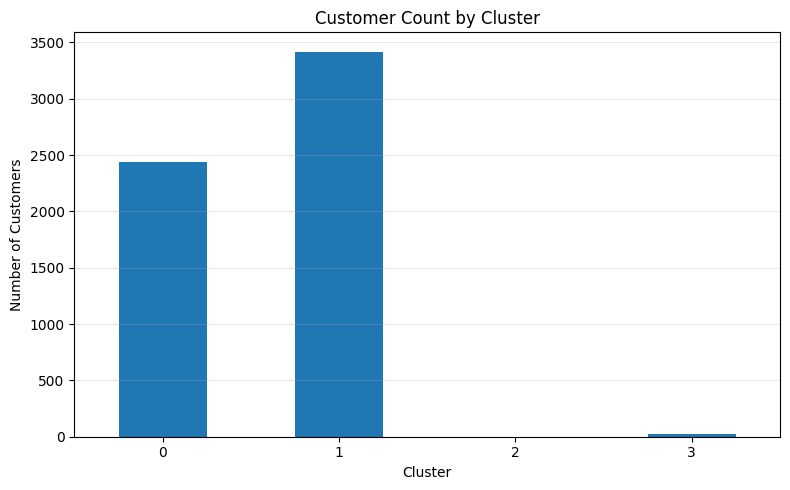

In [130]:
# ==========================================================
# Customer Count by Cluster
# ==========================================================

plt.figure(figsize=(8,5))

cluster_sizes.plot(kind="bar")

plt.title("Customer Count by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/figures/customer_count_by_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Section Summary

In this section, we visualized the customer segments using PCA and compared key customer metrics across clusters. These visualizations highlight the differences in customer behaviour and make the segmentation results easier to interpret.

The generated figures will be used in the project report and GitHub documentation to communicate the findings effectively.

In [131]:
cluster_profile.round(2)

,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,AvgRevenue,...,AvgDaysBetweenPurchases,CancelledTransactions,CancelledRevenue,CancellationRate,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend,CustomerCount
Cluster,,,,,,,,,,,,,,,,,,,,,
0,350.99,1.57,532.81,344.72,20.84,17.79,54.56,10.23,12.14,340.07,...,16.59,0.24,-50.26,7.73,340.07,0.76,19.00,-0.35,-120.52,2434
1,95.84,8.79,3534.28,2104.41,18.00,12.69,112.98,2.95,18.96,373.09,...,114.86,1.91,-119.98,14.54,373.09,0.02,16.83,0.12,23.67,3418
2,1.00,2.00,168472.49,80997.00,26999.00,1.00,80995.00,1.00,46761.91,84236.24,...,204.00,2.00,-168478.59,50.00,84236.24,0.01,1.50,2.00,168472.49,1
3,61.36,123.28,153172.21,96040.96,382.64,237.00,4826.28,28.32,798.50,3076.71,...,9.80,28.36,-12915.50,19.99,3076.71,0.29,5.56,-4.56,8299.64,25


# Section 10: Business Insights

## Objective

After profiling the customer clusters, we interpret each segment from a business perspective.

Instead of treating the clusters as numerical labels, we assign meaningful business names based on purchasing behaviour, spending patterns, customer activity, and recency.

These customer segments help businesses design targeted marketing campaigns, improve customer retention, and maximize revenue.

In [132]:
# ==========================================================
# Assign Business Names to Clusters
# ==========================================================

cluster_names = {
    0: "VIP Customers",
    1: "Regular Customers",
    2: "Exceptional High-Value Customer",
    3: "At-Risk Customers"
}

df["CustomerSegment"] = df["Cluster"].map(cluster_names)

df[["CustomerID", "Cluster", "CustomerSegment"]].head()

,CustomerID,Cluster,CustomerSegment
0,12346.0,3,At-Risk Customers
1,12347.0,1,Regular Customers
2,12348.0,1,Regular Customers
3,12349.0,1,Regular Customers
4,12350.0,0,VIP Customers


In [133]:
segment_distribution = (
    df["CustomerSegment"]
      .value_counts()
      .to_frame("Customer Count")
)

segment_distribution

,Customer Count
CustomerSegment,
Regular Customers,3418
VIP Customers,2434
At-Risk Customers,25
Exceptional High-Value Customer,1


In [134]:
business_summary = pd.DataFrame({
    "Segment": [
        "VIP Customers",
        "Regular Customers",
        "Exceptional High-Value Customer",
        "At-Risk Customers"
    ],

    "Business Interpretation": [
        "Highest spending and most loyal customers with frequent purchases.",
        "Largest customer group with moderate purchasing behaviour.",
        "A unique customer with exceptionally high spending that behaves differently from all other customers.",
        "Customers with low spending, very low purchase frequency and long inactivity period."
    ],

    "Recommended Strategy": [
        "Exclusive rewards, premium membership, early product access.",
        "Personalized offers and cross-selling recommendations.",
        "Assign dedicated account management and monitor individually.",
        "Retention campaigns, discounts and re-engagement emails."
    ]
})

business_summary

,Segment,Business Interpretation,Recommended Strategy
0,VIP Customers,Highest spending and most loyal customers with...,"Exclusive rewards, premium membership, early p..."
1,Regular Customers,Largest customer group with moderate purchasin...,Personalized offers and cross-selling recommen...
2,Exceptional High-Value Customer,A unique customer with exceptionally high spen...,Assign dedicated account management and monito...
3,At-Risk Customers,"Customers with low spending, very low purchase...","Retention campaigns, discounts and re-engageme..."


In [135]:
business_summary.to_csv(
    "../data/processed/business_segment_summary.csv",
    index=False
)

business_summary

,Segment,Business Interpretation,Recommended Strategy
0,VIP Customers,Highest spending and most loyal customers with...,"Exclusive rewards, premium membership, early p..."
1,Regular Customers,Largest customer group with moderate purchasin...,Personalized offers and cross-selling recommen...
2,Exceptional High-Value Customer,A unique customer with exceptionally high spen...,Assign dedicated account management and monito...
3,At-Risk Customers,"Customers with low spending, very low purchase...","Retention campaigns, discounts and re-engageme..."


### Section Summary

The numerical cluster labels were converted into meaningful business segments based on customer purchasing behaviour.

Each segment represents a distinct customer group with different purchasing characteristics and business value.

These insights allow organizations to implement targeted marketing strategies, improve customer retention, and maximize long-term revenue.

# Section 11: Save Results & Phase Summary

## Objective

In the final section of this phase, we save the customer segmentation results for use in the subsequent phases of the project.

The final dataset contains:

- Engineered customer features
- Cluster labels
- Business-friendly customer segment names

This dataset will be used in later phases for customer churn prediction, recommendation systems, dashboard development, and deployment.

In [136]:
# ==========================================================
# Save Final Customer Segmentation Dataset
# ==========================================================

output_path = "../data/processed/customer_segments.csv"

df.to_csv(output_path, index=False)

print("Customer segmentation dataset saved successfully.")
print(f"Location: {output_path}")

Customer segmentation dataset saved successfully.
Location: ../data/processed/customer_segments.csv


In [137]:
# ==========================================================
# Verify Saved Dataset
# ==========================================================

saved_df = pd.read_csv(output_path)

print("Dataset Shape:", saved_df.shape)

saved_df.head()

Dataset Shape: (5878, 33)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AvgQuantity,MedianQuantity,MaxQuantity,MinQuantity,QuantitySTD,...,CancelledRevenue,CancellationRate,Country,AverageBasketValue,PurchaseVelocity,ProductDiversityRatio,PurchaseTrend,RevenueTrend,Cluster,CustomerSegment
0,12346.0,326,12,77556.46,74285,2184.852941,1.0,74215,1,12727.403892,...,-77608.20,29.411765,United Kingdom,6463.038333,0.029925,2.25,-10.0,76810.74,3,At-Risk Customers
1,12347.0,2,8,4921.53,2967,13.364865,12.0,240,2,17.337408,...,0.00,0.000000,Iceland,615.191250,0.019851,15.75,6.0,3698.47,1,Regular Customers
2,12348.0,75,5,2019.40,2714,53.215686,24.0,144,1,48.700848,...,0.00,0.000000,Finland,403.880000,0.013774,5.00,3.0,1575.08,1,Regular Customers
3,12349.0,19,4,4428.69,1624,9.280000,6.0,48,1,7.770886,...,-24.15,20.000000,Italy,1107.172500,0.007005,34.50,-2.0,-913.59,1,Regular Customers
4,12350.0,310,1,334.40,197,11.588235,12.0,24,1,4.345383,...,0.00,0.000000,Norway,334.400000,1.000000,17.00,1.0,334.40,0,VIP Customers


In [138]:
# ==========================================================
# Final Dataset Columns
# ==========================================================

print("Final Columns:\n")

for i, column in enumerate(saved_df.columns, start=1):
    print(f"{i}. {column}")

Final Columns:

1. CustomerID
2. Recency
3. Frequency
4. Monetary
5. TotalQuantity
6. AvgQuantity
7. MedianQuantity
8. MaxQuantity
9. MinQuantity
10. QuantitySTD
11. AvgRevenue
12. MedianRevenue
13. MaxRevenue
14. MinRevenue
15. RevenueSTD
16. RevenueRange
17. UniqueProducts
18. AvgProductsPerInvoice
19. ActiveMonths
20. PurchaseSpan
21. WeekendPurchaseRate
22. AvgDaysBetweenPurchases
23. CancelledTransactions
24. CancelledRevenue
25. CancellationRate
26. Country
27. AverageBasketValue
28. PurchaseVelocity
29. ProductDiversityRatio
30. PurchaseTrend
31. RevenueTrend
32. Cluster
33. CustomerSegment


In [139]:
# ==========================================================
# Customer Segment Distribution
# ==========================================================

saved_df["CustomerSegment"].value_counts()

CustomerSegment
Regular Customers                  3418
VIP Customers                      2434
At-Risk Customers                    25
Exceptional High-Value Customer       1
Name: count, dtype: int64

In [140]:
# ==========================================================
# Dataset Information
# ==========================================================

saved_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               5878 non-null   float64
 1   Recency                  5878 non-null   int64  
 2   Frequency                5878 non-null   int64  
 3   Monetary                 5878 non-null   float64
 4   TotalQuantity            5878 non-null   int64  
 5   AvgQuantity              5878 non-null   float64
 6   MedianQuantity           5878 non-null   float64
 7   MaxQuantity              5878 non-null   int64  
 8   MinQuantity              5878 non-null   int64  
 9   QuantitySTD              5878 non-null   float64
 10  AvgRevenue               5878 non-null   float64
 11  MedianRevenue            5878 non-null   float64
 12  MaxRevenue               5878 non-null   float64
 13  MinRevenue               5878 non-null   float64
 14  RevenueSTD              

# Phase 5 Summary

## What We Accomplished

In this phase, we successfully segmented customers into meaningful groups based on their purchasing behaviour using the K-Means clustering algorithm.

### Major Steps Completed

- Loaded the engineered customer feature dataset.
- Explored customer features and their distributions.
- Performed correlation analysis.
- Standardized numerical features using StandardScaler.
- Reduced dimensionality for visualization using PCA.
- Determined the optimal number of clusters using the Elbow Method and Silhouette Score.
- Applied K-Means clustering to segment customers.
- Profiled each customer segment using average behavioural features.
- Visualized customer clusters and segment characteristics.
- Assigned meaningful business names to each customer segment.
- Saved the final customer segmentation dataset.

## Final Output

Generated Files:

- `customer_segments.csv`
- `cluster_profile.csv`
- `business_segment_summary.csv`

Generated Figures:

- `elbow_curve.png`
- `silhouette_scores.png`
- `customer_segments.png`
- `revenue_by_segment.png`

## Key Business Insights

- A small group of **VIP Customers** contributes a disproportionately large share of revenue.
- **Regular Customers** form the largest active customer segment and represent opportunities for cross-selling and upselling.
- An **Exceptional High-Value Customer** was identified as a unique outlier requiring individual analysis.
- **At-Risk Customers** exhibit low spending, infrequent purchases, and long periods of inactivity, making them ideal candidates for retention campaigns.

## Conclusion

Customer segmentation transforms raw transactional data into actionable business intelligence. By understanding different customer behaviours, businesses can design personalized marketing strategies, improve customer retention, optimize resource allocation, and increase long-term profitability.

The segmented dataset generated in this phase serves as the foundation for the remaining phases of the Intelligent Customer Analytics Platform.

In [141]:
for var in sorted(globals()):
    if "segment" in var.lower() or "cluster" in var.lower():
        print(var)

cluster_centers
cluster_counts
cluster_names
cluster_percentage
cluster_profile
cluster_sizes
cluster_summary
clusters
customer_segments
segment_distribution
segment_summary


In [142]:
customer_segments = X.copy()

customer_segments["Cluster"] = clusters

customer_segments["CustomerSegment"] = customer_segments["Cluster"].map(cluster_names)

In [143]:
# ==========================================================
# SAVE SEGMENTATION ARTIFACTS
# ==========================================================

from pathlib import Path
import pandas as pd
import json

artifact_dir = Path("../artifacts/segmentation")
artifact_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------
# Customer Segments
# ----------------------------------------------------------

customer_segments = X.copy()

customer_segments["Cluster"] = clusters

customer_segments["CustomerSegment"] = customer_segments["Cluster"].map(cluster_names)

customer_segments.to_csv(
    artifact_dir / "customer_segments.csv",
    index=False
)

# ----------------------------------------------------------
# Segment Summary
# ----------------------------------------------------------

segment_summary = (
    customer_segments
    .groupby("CustomerSegment")
    .agg(
        CustomerCount=("CustomerSegment", "size"),
        AverageRecency=("Recency", "mean"),
        AverageFrequency=("Frequency", "mean"),
        TotalRevenue=("Monetary", "sum"),
        AverageRevenue=("Monetary", "mean"),
        MinRevenue=("Monetary", "min"),
        MaxRevenue=("Monetary", "max"),
        AvgQuantity=("AvgQuantity", "mean"),
        AvgRevenuePerCustomer=("AvgRevenue", "mean"),
    )
    .reset_index()
)

segment_summary.to_csv(
    artifact_dir / "segment_summary.csv",
    index=False
)

# ----------------------------------------------------------
# Cluster Centers
# ----------------------------------------------------------

if isinstance(cluster_centers, pd.DataFrame):
    cluster_centers.to_csv(
        artifact_dir / "cluster_centers.csv",
        index=False
    )
else:
    pd.DataFrame(cluster_centers).to_csv(
        artifact_dir / "cluster_centers.csv",
        index=False
    )

# ----------------------------------------------------------
# KMeans Metrics
# ----------------------------------------------------------

metrics = pd.DataFrame({
    "Metric": [
        "Clusters",
        "Inertia"
    ],
    "Value": [
        kmeans.n_clusters,
        kmeans.inertia_
    ]
})

metrics.to_csv(
    artifact_dir / "kmeans_metrics.csv",
    index=False
)

# ----------------------------------------------------------
# Silhouette Score
# ----------------------------------------------------------

try:
    score = float(silhouette_score(X_scaled, clusters))
except:
    score = None

with open(
    artifact_dir / "silhouette_score.json",
    "w"
) as f:

    json.dump(
        {
            "silhouette_score": score
        },
        f,
        indent=4
    )

print("="*60)
print("Segmentation artifacts saved successfully.")
print("="*60)
print("Files Saved:")
print("customer_segments.csv")
print("segment_summary.csv")
print("cluster_centers.csv")
print("kmeans_metrics.csv")
print("silhouette_score.json")
print("="*60)

Segmentation artifacts saved successfully.
Files Saved:
customer_segments.csv
segment_summary.csv
cluster_centers.csv
kmeans_metrics.csv
silhouette_score.json


In [144]:
import pandas as pd

df = pd.read_csv("../artifacts/segmentation/segment_summary.csv")

print(df.columns.tolist())
display(df)

['CustomerSegment', 'CustomerCount', 'AverageRecency', 'AverageFrequency', 'TotalRevenue', 'AverageRevenue', 'MinRevenue', 'MaxRevenue', 'AvgQuantity', 'AvgRevenuePerCustomer']


,CustomerSegment,CustomerCount,AverageRecency,AverageFrequency,TotalRevenue,AverageRevenue,MinRevenue,MaxRevenue,AvgQuantity,AvgRevenuePerCustomer
0,At-Risk Customers,25,61.360000,123.280000,3829305.35,153172.214000,27246.88,580987.04,382.636782,3076.711296
1,Exceptional High-Value Customer,1,1.000000,2.000000,168472.49,168472.490000,168472.49,168472.49,26999.000000,84236.245000
2,Regular Customers,3418,95.840257,8.794909,12080156.15,3534.276229,30.95,88612.52,18.002823,373.087635
3,VIP Customers,2434,350.990961,1.571076,1296870.25,532.814400,2.95,23691.40,20.841245,340.067958
